# Discharge data analysis of the Katsaoka river with 2002 hourly data from January to December
This is a small data analysis project to identify daily mean discharge for the river for each month, monthly discharge histogram, maximal discharge plots and finally finding the maximum peak discharge of the year.
First of all we will be importing all the needed libraries

In [2]:
library("ggplot2")
library("readxl")
library("dplyr")
library("lubridate")
library("writexl")

# Data generation and extraction
First we are extracting the hourly data and convert it into daily data on specific file for each months .
Note that the data used is an xls file containing hourly discharge from January to December 2002. 

In [3]:
sheets = c("Janv_02","Fév_02","Mars_02","Avril_02","Mai_02","Juin_02","Juil_02","Août_02","Sept_02","Oct_02","Nov_02","Déc_02")
for (i in 1:length(sheets)){
df = read_excel("/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Hauteur_Débit_Katsaoka_2002 b.xls",sheet = sheets[i])
df = df%>%
group_by(day(Date))%>%
summarize(Hauteur = mean(Hauteur),Débit = mean(Débit))
print(write_xlsx(df,paste("/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_",sheets[i],".xlsx")))
}


[1] "/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Janv_02 .xlsx"
[1] "/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Fév_02 .xlsx"
[1] "/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Mars_02 .xlsx"
[1] "/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Avril_02 .xlsx"
[1] "/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Mai_02 .xlsx"
[1] "/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Juin_02 .xlsx"
[1] "/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Juil_02 .xlsx"
[1] "/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Août_02 .xlsx"
[1] "/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Sept_02 .xlsx"
[1] "/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Oct_02 .xlsx"
[1] "/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/

# Histogram of monthly discharge for the year
Now we are summarizing the daily data and get an histogram illustrating monthly discharge for the year

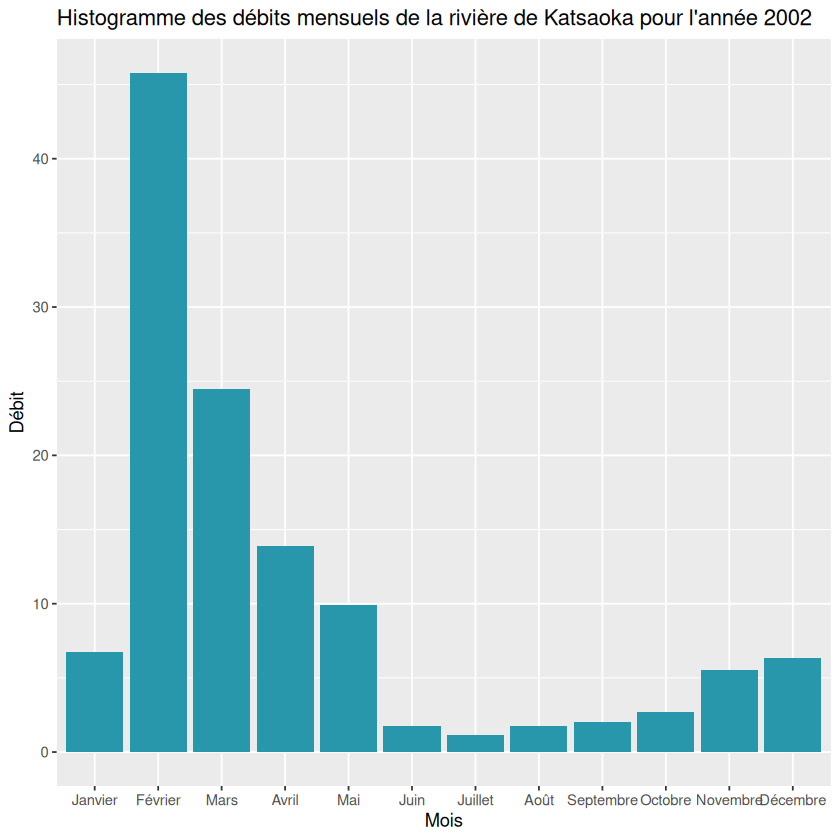

In [4]:
files = c("/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Janv_02 .xlsx",
"/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Fév_02 .xlsx",
"/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Mars_02 .xlsx",
"/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Avril_02 .xlsx",
"/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Mai_02 .xlsx",
"/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Juin_02 .xlsx",
"/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Juil_02 .xlsx",
"/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Août_02 .xlsx",
"/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Sept_02 .xlsx",
"/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Oct_02 .xlsx",
"/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Nov_02 .xlsx",
"/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Data_ Déc_02 .xlsx")
monthly_discharge = c(rep(0,12))
for(i in 1:length(files)){
    data = read_excel(files[i])
    monthly_discharge[i] = mean(data$Débit)

}
months = c("Janvier","Février","Mars","Avril","Mai","Juin","Juillet","Août","Septembre","Octobre","Novembre","Décembre")
data = data.frame(month = months,discharge = monthly_discharge)
data$month = factor(data$month,levels = data$month)
bars = ggplot(mapping = aes(x = data$month,y = data$discharge))+
geom_col(fill = "#2997ab")+
labs(title = "Histogramme des débits mensuels de la rivière de Katsaoka pour l'année 2002",x = "Mois",y = "Débit")
print(bars)

# maximum discharge for each month 
Here we are building lineplot that shows the evolution of maximum discharge per month

 [1]  22.359497 168.217561  59.365078  23.863454  17.611677   5.698564
 [7]   1.390661   2.553209   4.205647  14.176308  23.351218  29.646324


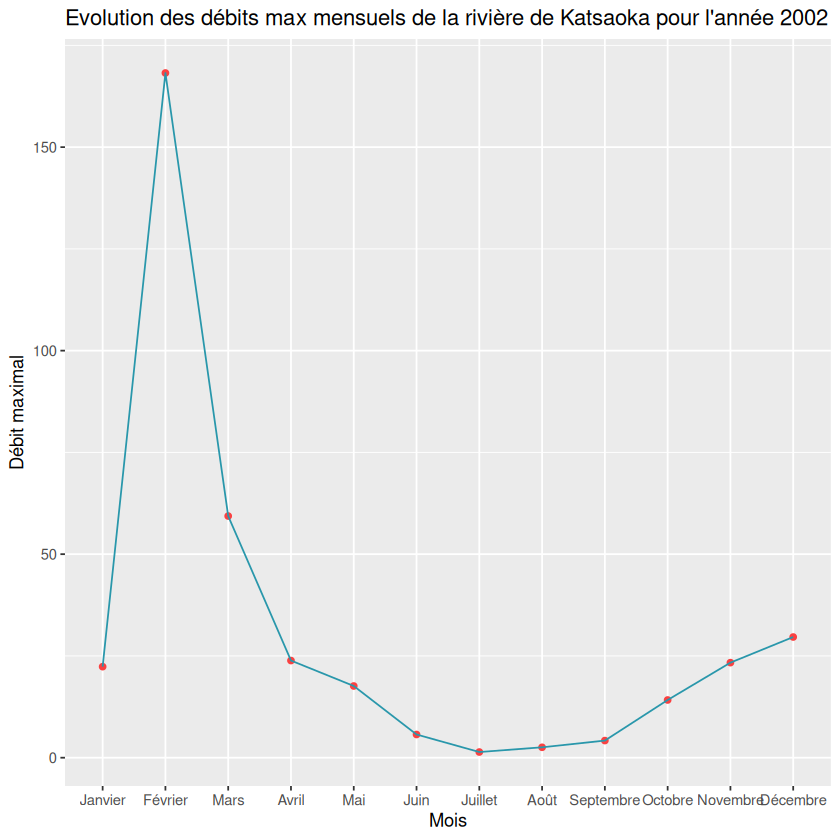

In [5]:
max_discharge = c(rep(0,12))
for(i in 1:length(files)){
    data = read_excel("/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Hauteur_Débit_Katsaoka_2002 b.xls",sheet = sheets[i])
    max_discharge[i] = max(data$Débit)

}
print(max_discharge)
data2 = data.frame(month = months,discharge = max_discharge)
data2$month = factor(data2$month,levels = data2$month)
lines = ggplot(mapping = aes(x = data2$month,y = data2$discharge,group = 1))+
geom_point(color = "#fa4141ff")+
geom_line(mapping = aes(x = data2$month,y = data2$discharge),color = "#2997ab")+
labs(title = "Evolution des débits max mensuels de la rivière de Katsaoka pour l'année 2002",x = "Mois",y = "Débit maximal")
print(lines)

# Finding the maximum peak discharge 
As we can see on the maximum discharge plot above, the peak is seen on February. Now we are finding the exact date of this event.

In [6]:
february = read_excel("/media/dina/f4c07323-3819-4c76-ad53-95f7d45b7ae2/Katsaoka/Katsaoka/Hauteur_Débit_Katsaoka_2002 b.xls",sheet = "Fév_02")

february%>%
filter(Débit == max(Débit))

Date,Hauteur,Débit,Hours
<dttm>,<dbl>,<dbl>,<dbl>
2002-02-13 09:00:00,3.54,168.2176,297


So, as we can see the peak event is located on February 13th, with a discharge of 168.32 m3/s.

# Building hydrogram 
Now we are building the hydrogram by using hourly discharge data

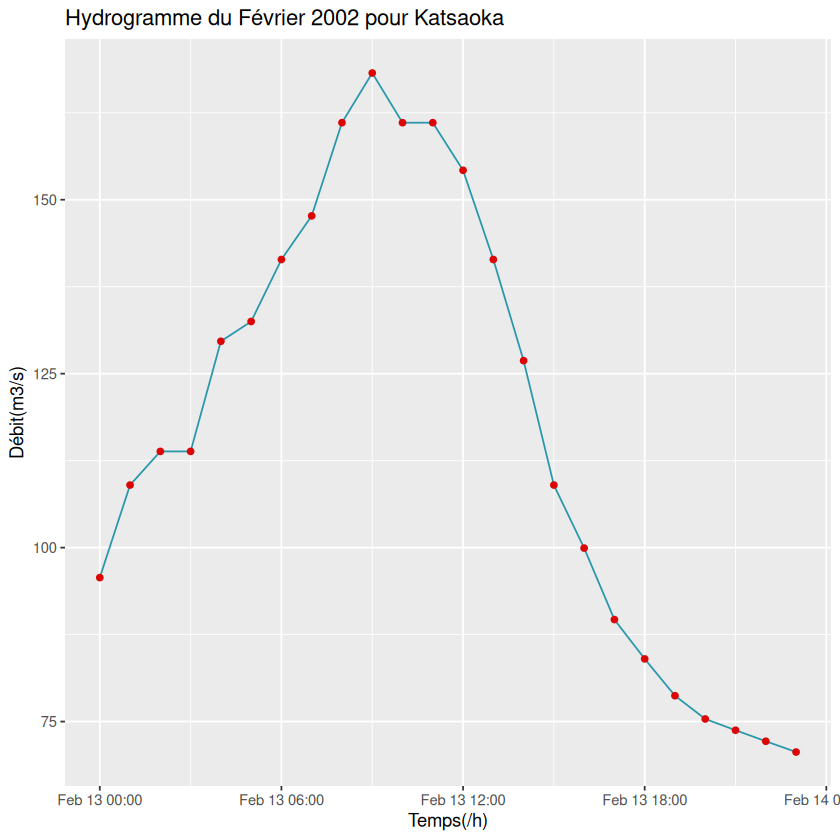

In [7]:
feb = february%>%
filter(day(Date) == 13)
hydr = ggplot(data = feb,mapping = aes(x = Date,y = Débit))+
geom_line(color = "#2997ab")+
geom_point(color = "#db0505ff")+
labs(title = "Hydrogramme du Février 2002 pour Katsaoka",x = "Temps(/h)",y = "Débit(m3/s)")
print(hydr)

# Adjusting hydrogram by using log10 transformation
We are going to find the starting point and the end of the flood. For that it's needed to transform the scale into logarithmic scale.

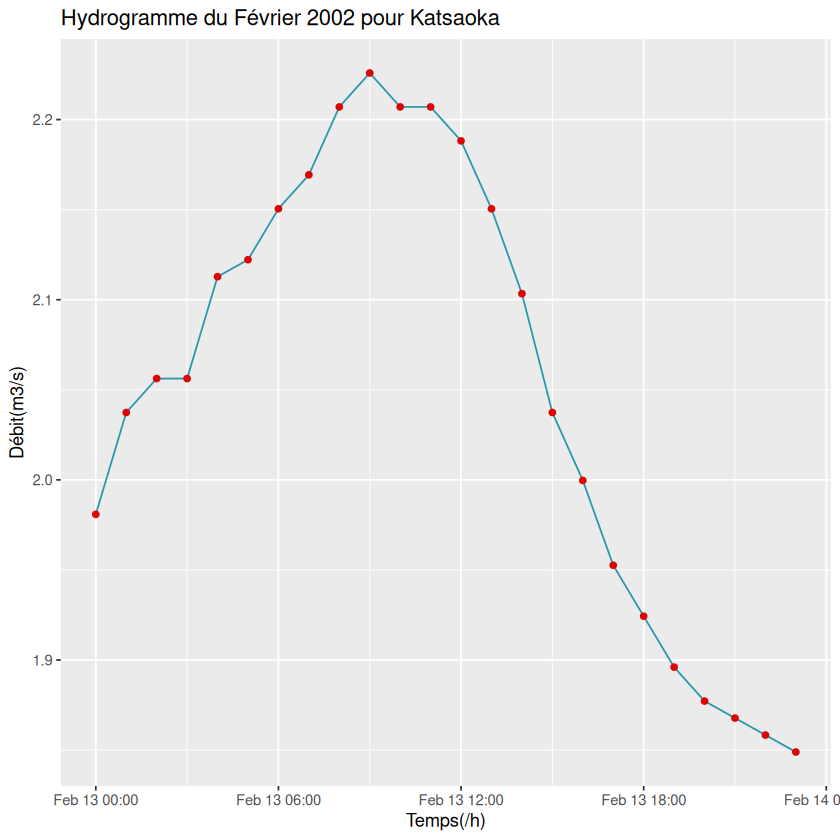

In [13]:
hydr = ggplot(data = feb,mapping = aes(x = Date,y = log10(Débit)))+
geom_line(color = "#2997ab")+
geom_point(color = "#db0505ff")+
labs(title = "Hydrogramme du Février 2002 pour Katsaoka",x = "Temps(/h)",y = "Débit(m3/s)")
print(hydr)

As we can see, there are two peak.The first starting point of increase lays on  February 12th at 01:00 Am.
The response time after calculating is 10 hours from increase start to peak for the first flood. The end of the flood is located at 06:00 PM.